# **Global Data Science Job Salary Analysis**
**____________________________________________________________________**

# **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


import plotly.express as px

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

pd.set_option("display.max_columns", None)

# **Read the Raw Data CSV File**

In [2]:
jobs = pd.read_csv('https://raw.githubusercontent.com/jecka0627/ds_global_job_salaries/refs/heads/main/ds_job_salaries.csv')

#**Dataset Overview**
In this section, I performed the initial inspection of the dataset, such as how many rows and columns, the number of unique value, and a preview of the data (the first 10 rows).

In [3]:
print("Dataset Shape:", jobs.shape) #Dataset shape
print("Unique job titles:", jobs["job_title"].nunique()) #job titles available
print("Countries represented:", jobs["company_location"].nunique()) # countries available

print("First Ten Rows: ")
jobs.head(10)

Dataset Shape: (3755, 11)
Unique job titles: 93
Countries represented: 72
First Ten Rows: 


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M
5,2023,SE,FT,Applied Scientist,222200,USD,222200,US,0,US,L
6,2023,SE,FT,Applied Scientist,136000,USD,136000,US,0,US,L
7,2023,SE,FT,Data Scientist,219000,USD,219000,CA,0,CA,M
8,2023,SE,FT,Data Scientist,141000,USD,141000,CA,0,CA,M
9,2023,SE,FT,Data Scientist,147100,USD,147100,US,0,US,M


# **Understanding the Data**
This is the section where I explore the dataset by examining its structure, data types, and summary statistics to gain a better understanding of the available information.

In [4]:
#Column Names
jobs.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='object')

In [5]:
#Data Types
jobs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3755 entries, 0 to 3754
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           3755 non-null   int64 
 1   experience_level    3755 non-null   object
 2   employment_type     3755 non-null   object
 3   job_title           3755 non-null   object
 4   salary              3755 non-null   int64 
 5   salary_currency     3755 non-null   object
 6   salary_in_usd       3755 non-null   int64 
 7   employee_residence  3755 non-null   object
 8   remote_ratio        3755 non-null   int64 
 9   company_location    3755 non-null   object
 10  company_size        3755 non-null   object
dtypes: int64(4), object(7)
memory usage: 322.8+ KB


In [6]:
#Descriptive Statistics
jobs.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,3755.000000,3.755000e+03,3755.000000,3755.000000
mean,2022.373635,1.906956e+05,137570.389880,46.271638
std,0.691448,6.716765e+05,63055.625278,48.589050
min,2020.000000,6.000000e+03,5132.000000,0.000000
25%,2022.000000,1.000000e+05,95000.000000,0.000000
50%,2022.000000,1.380000e+05,135000.000000,0.000000
75%,2023.000000,1.800000e+05,175000.000000,100.000000
max,2023.000000,3.040000e+07,450000.000000,100.000000


Salary distribution is highly skewed in raw salary values due to extreme outliers. Which is why salary in USD is a more reliable metric for comparison and analysis.

The dataset contains salary information for 3755 data science roles across 72 different countries and 93 job titles



# **DATA CLEANING**

### **CHECKING MISSING VALUES**

In [7]:
jobs.isnull().sum()

,0
work_year,0
experience_level,0
employment_type,0
job_title,0
salary,0
salary_currency,0
salary_in_usd,0
employee_residence,0
remote_ratio,0
company_location,0


### **CHECKING DUPLICATES**

In [8]:
jobs.duplicated().sum()

np.int64(1171)

In [9]:
jobs[jobs.duplicated(keep=False)].sort_values(by=list(jobs.columns))

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
3119,2020,EN,FT,Data Engineer,1000000,INR,13493,IN,100,IN,L
3120,2020,EN,FT,Data Engineer,1000000,INR,13493,IN,100,IN,L
3502,2021,MI,FT,Data Engineer,200000,USD,200000,US,100,US,L
3586,2021,MI,FT,Data Engineer,200000,USD,200000,US,100,US,L
3665,2021,MI,FT,Data Scientist,76760,EUR,90734,DE,50,DE,L
...,...,...,...,...,...,...,...,...,...,...,...
525,2023,SE,FT,Research Scientist,250000,USD,250000,US,0,US,M
956,2023,SE,FT,Research Scientist,250000,USD,250000,US,0,US,M
1751,2023,SE,FT,Research Scientist,250000,USD,250000,US,0,US,M
1247,2023,SE,FT,Research Scientist,253750,USD,253750,ES,0,ES,M


No missing values but duplicate rows were detected in the dataset. Since these records contain identical information across all variables, they are likely the result of dataset aggregation or export issues.

So, removing duplicates ensures that salary statistics are not artificially inflated.

In [10]:
jobs= jobs.drop_duplicates()
jobs.duplicated().sum()

np.int64(0)

In [11]:
print("Dataset Shape:", jobs.shape) #Dataset shape
print("Unique job titles:", jobs["job_title"].nunique()) #job titles available
print("Countries represented:", jobs["company_location"].nunique()) # countries available
print()
jobs.info()

Dataset Shape: (2584, 11)
Unique job titles: 93
Countries represented: 72

<class 'pandas.core.frame.DataFrame'>
Index: 2584 entries, 0 to 3754
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           2584 non-null   int64 
 1   experience_level    2584 non-null   object
 2   employment_type     2584 non-null   object
 3   job_title           2584 non-null   object
 4   salary              2584 non-null   int64 
 5   salary_currency     2584 non-null   object
 6   salary_in_usd       2584 non-null   int64 
 7   employee_residence  2584 non-null   object
 8   remote_ratio        2584 non-null   int64 
 9   company_location    2584 non-null   object
 10  company_size        2584 non-null   object
dtypes: int64(4), object(7)
memory usage: 242.2+ KB


After the removal of the duplicates our cleaned dataset contains salary information for 2584 data science roles across 72 different countries and 93 job titles

# **EXPLORATORY DATA ANALYSIS**

This is where I explore patterns across different context such as experience level, company size, and work arrangements

### **Exploring Categorical Columns**

In [12]:
#Job Titles
jobs['job_title'].value_counts().head(10)

,count
job_title,
Data Engineer,598
Data Scientist,538
Data Analyst,396
Machine Learning Engineer,206
Analytics Engineer,91
Research Scientist,65
Data Architect,64
Data Science Manager,52
ML Engineer,34


### **Salary Analysis**

In [13]:
#Average Salary
jobs['salary_in_usd'].mean()

np.float64(133409.28018575851)

In [14]:
#Highest Salary
jobs['salary_in_usd'].max()

450000

In [15]:
#Lowest Salary
jobs['salary_in_usd'].min()

5132

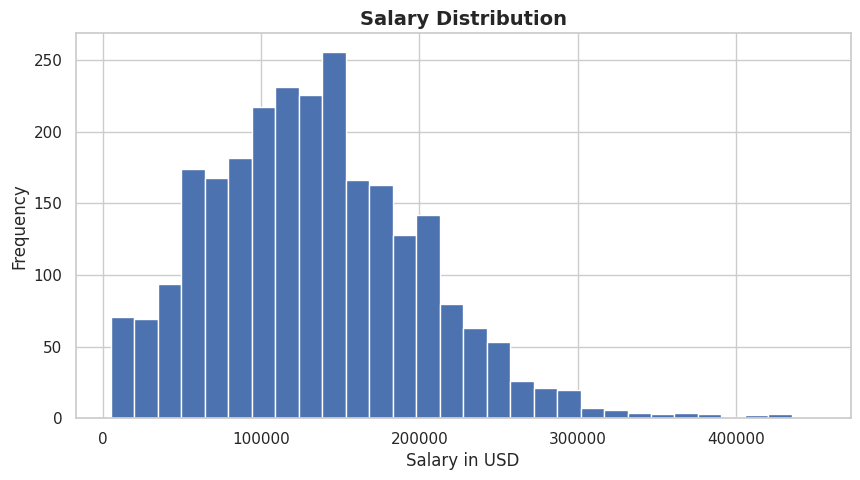

In [16]:
#SALARY DISTRIBUTION
plt.figure(figsize=(10,5))
plt.hist(jobs['salary_in_usd'], bins=30)
plt.xlabel('Salary in USD')
plt.ylabel('Frequency')
plt.title('Salary Distribution')
plt.show()

As the salary distribution is still highly skewed even after using the USD currency, means that the dataset contains extreme values that can distort the mean. So, I'll be using the median salary throughout the analysis as the central tendency, which will reduce the influence of the extreme values.

### **Salary by Experience Level Analysis**

In [17]:
exp_order = ['EN', 'MI', 'SE', 'EX']
exp_labels = {'EN': 'Entry-level', 'MI': 'Mid-level', 'SE': 'Senior', 'EX': 'Executive'}

jobs['experience_level'].map(exp_labels).value_counts().reindex(['Entry-level', 'Mid-level', 'Senior', 'Executive'])

,count
experience_level,
Entry-level,270
Mid-level,664
Senior,1554
Executive,96


In [18]:
jobs.groupby('experience_level')['salary_in_usd'].median().reindex(exp_order).rename(exp_labels)

,salary_in_usd
experience_level,
Entry-level,61900.0
Mid-level,95000.0
Senior,148800.0
Executive,189618.5


Salary shows a clear upward progression with experience — from a median of 62K USD at Entry-level, up to 190K USD at Executive level. The salary spread also widens at higher levels, indicating greater compensation variability among senior and executive roles.

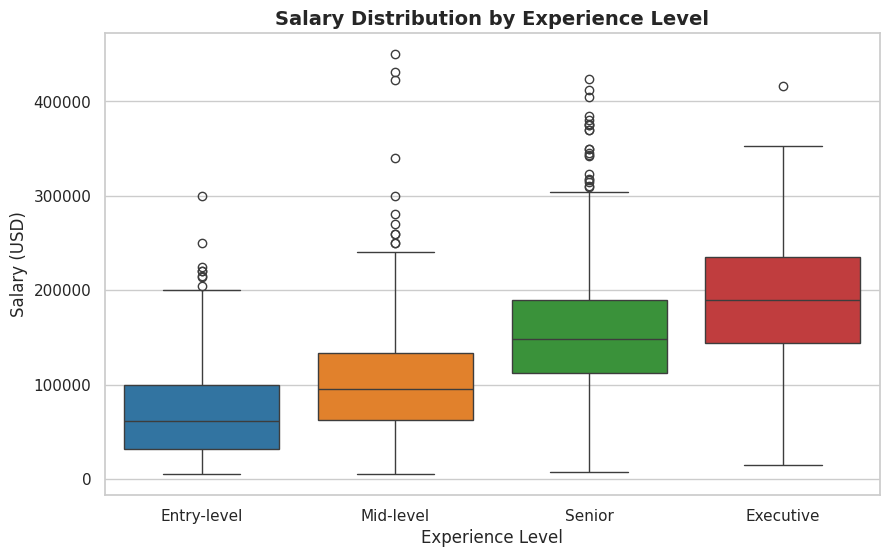

In [19]:
exp_order = ['EN', 'MI', 'SE', 'EX']
exp_labels = {'EN': 'Entry-level', 'MI': 'Mid-level', 'SE': 'Senior', 'EX': 'Executive'}

jobs['exp_label'] = jobs['experience_level'].map(exp_labels)
order_labels = ['Entry-level', 'Mid-level', 'Senior', 'Executive']

sns.boxplot(
    x='exp_label',
    y='salary_in_usd',
    data=jobs,
    order=order_labels,
    palette='tab10'
)

plt.title('Salary Distribution by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Salary (USD)')
plt.show()

In [20]:
jobs[jobs["salary_in_usd"] > 400000][["job_title","experience_level","company_location"]]

,job_title,experience_level,company_location
528,AI Scientist,SE,IL
2011,Data Analyst,MI,GB
3463,Data Analytics Lead,SE,US
3522,Research Scientist,MI,US
3675,Principal Data Scientist,EX,US
3747,Applied Machine Learning Scientist,MI,US
3750,Data Scientist,SE,US


Salaries above 400K USD were observed across multiple experience levels, including mid-level roles such as Data Analyst and Research Scientist, primarily in high-paying regions like the US and IL. These valid high-compensation cases were retained in the analysis, as they highlight that job role and location can strongly influence salary beyond experience level alone.

### **Salary by Company Size Analysis**

In [21]:
#Company Size
jobs['company_size'].value_counts()

,count
company_size,
M,2028
L,409
S,147


In [22]:
jobs["company_size"].value_counts(normalize=True)

,proportion
company_size,
M,0.784830
L,0.158282
S,0.056889


The dataset shows an uneven but sufficiently large distribution of company sizes, with medium-sized companies dominating the sample (≈78.5%), followed by large companies (≈15.8%), and small companies (≈5.7%). While the dataset is not perfectly balanced, each category contains enough observations to support meaningful comparison of salary patterns across company sizes.

In [23]:
jobs.groupby('company_size')['salary_in_usd'].median()

,salary_in_usd
company_size,
L,100000.0
M,137067.5
S,62726.0


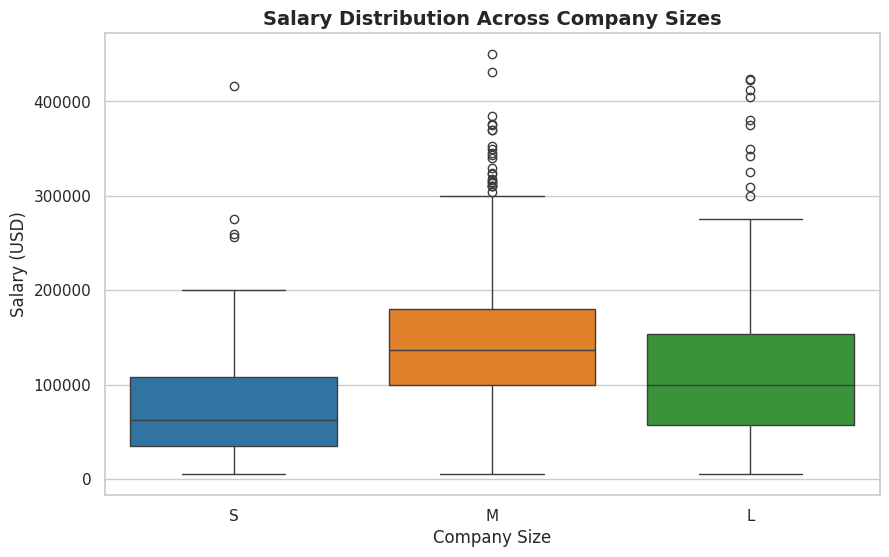

In [24]:
order= ["S", "M", "L"]

sns.boxplot(
    x="company_size",
    y="salary_in_usd",
    data=jobs,
    order=order,
    palette="tab10"
)

plt.title("Salary Distribution Across Company Sizes")
plt.xlabel("Company Size")
plt.ylabel("Salary (USD)")

plt.show()

Salary analysis reveals a clear relationship between company size and compensation levels. Medium-sized companies offer the highest median salary at approximately 137k, followed by large companies at 100k, while small companies report the lowest median salary at around 62.7k. This indicates the mid-sized organizations tend to provide more competitive compensation, potentially due to a balance between resource availability and organizational flexibility. In contrast, small companies appear to offer significantly lower pay, likely reflecting budget constraints, while large companies show moderate compensation levels with wider variability.

Overall, the results suggest that company size is a relevant factor in salary determination, with meduim-sized companies emerging as the most favorable in terms of median compensation within this dataset

### **Salary by Remote Work Analysis**

In [25]:
jobs["remote_ratio"].unique()

array([100,   0,  50])

In [26]:
jobs["remote_ratio"].value_counts()

,count
remote_ratio,
100,1211
0,1186
50,187


In [27]:
#The variable remote_ratio represents the proportion of remote work:
  #0 → On-site
  #50 → Hybrid
  #100 → Remote

jobs["remote_type"]= jobs["remote_ratio"].map({
    0: "On-site",
    50: "Hybrid",
    100: "Remote"
})

jobs['remote_type'].value_counts()

,count
remote_type,
Remote,1211
On-site,1186
Hybrid,187


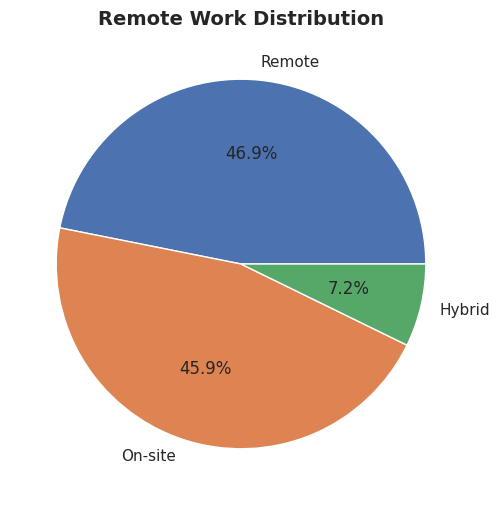

In [28]:
#REMOTE WORK DISTRIBUTION

remote_counts = jobs['remote_type'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(remote_counts.values, labels=remote_counts.index, autopct='%1.1f%%')
plt.title('Remote Work Distribution')
plt.show()

Remote (1,211) and On-site (1,186) are nearly equal in count, while Hybrid (187) is significantly underrepresented at only 7.2% of the dataset.

In [29]:
jobs.groupby('remote_type')['salary_in_usd'].median().sort_values(ascending=False)

,salary_in_usd
remote_type,
On-site,137500.0
Remote,130000.0
Hybrid,63312.0


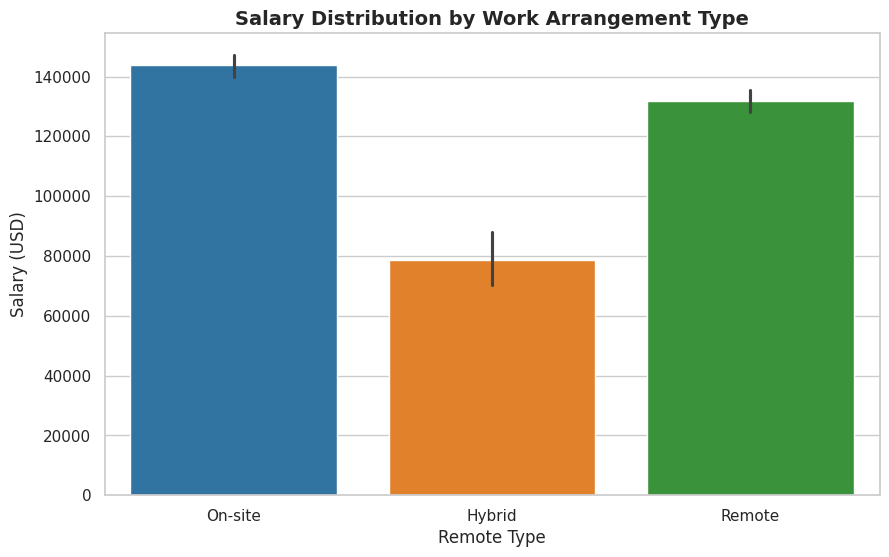

In [30]:
#to check which job type pays more
order= ["On-site", "Hybrid", "Remote"]

sns.barplot(x= "remote_type",
            y= "salary_in_usd",
            data= jobs,
            order=order,
            palette="tab10",
            )

plt.title("Salary Distribution by Work Arrangement Type")
plt.xlabel("Remote Type")
plt.ylabel("Salary (USD)")

plt.show()

The dataset shows that while remote work is the most common arrangement, on-site positions offer the highest median salary at $137,500, slightly above remote roles at 130,000 USD. Hybrid work trails significantly at 63,312 USD, though this may be due to its small sample size of only 187 entries. This suggests that compensation is likely influenced by job structure, seniority, or location-specific roles rather than work arrangement alone, meaning remote work itself is not the sole driver of higher salaries.

### **Salary by Country Analysis**

Company location is likely to have a strong effect on salary levels. In data-related roles, pay tends to vary across countries because of differences in cost of living, labor market conditions, and the demand for skilled professionals.

In [31]:
#Top Countries by Job Count
jobs['company_location'].value_counts().head(10)

,count
company_location,
US,1929
GB,155
CA,83
IN,57
DE,55
ES,44
FR,33
BR,15
AU,14


In [32]:
#Highest Paying Countries
jobs.groupby('company_location')['salary_in_usd'].median().sort_values(ascending=False).head(10)

,salary_in_usd
company_location,
IL,271446.5
PR,167500.0
US,145885.0
NZ,125000.0
BA,120000.0
CA,120000.0
AE,115000.0
RU,106000.0
SE,105000.0


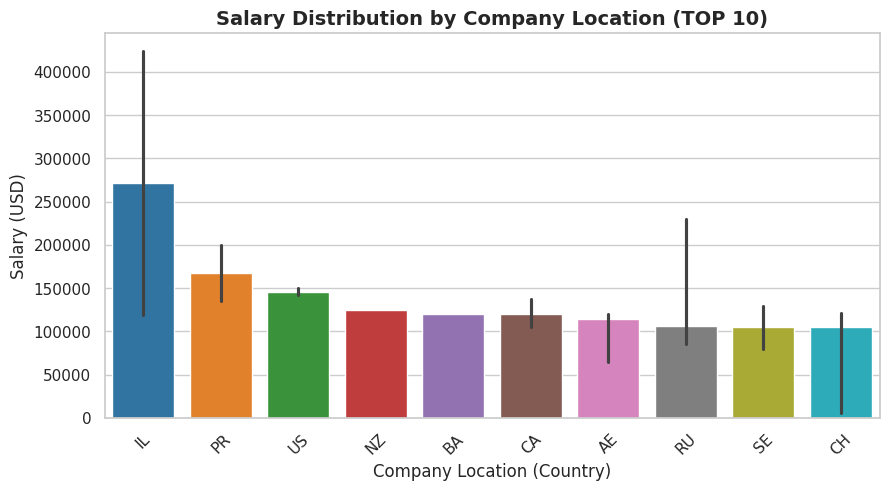

In [33]:
order = jobs.groupby('company_location')['salary_in_usd'].median().sort_values(ascending=False).head(10).index

plt.figure(figsize=(10,5))

sns.barplot(
    x="company_location",
    y="salary_in_usd",
    data=jobs,
    estimator=np.median,
    order=order,
    palette="tab10"
)

plt.title("Salary Distribution by Company Location (TOP 10)")
plt.xlabel("Company Location (Country)")
plt.ylabel("Salary (USD)")
plt.xticks(rotation=45)

plt.show()

While IL and PR show the highest median salaries, its wide variability and small sample sizes make these figures less reliable. High salaries don't always mean high opportunity, the US, despite ranking 3rd in salary, offers the best balance of compensation and job volume, making it the most data-rich and statistically robust benchmark for data science compensation globally.

### **Top Paying Job Titles**

In [34]:
jobs["job_title"].nunique()

93

In [35]:
jobs["job_title"].value_counts()

,count
job_title,
Data Engineer,598
Data Scientist,538
Data Analyst,396
Machine Learning Engineer,206
Analytics Engineer,91
...,...
Principal Data Architect,1
Head of Machine Learning,1
Cloud Data Architect,1


The dataset contains 93 unique job titles. To maintain clarity and statistical reliability, the analysis focuses on the 10 most frequently occurring roles.

In [36]:
top_jobs = jobs["job_title"].value_counts().head(10).index

df_jobs = jobs[jobs["job_title"].isin(top_jobs)]

df_jobs.groupby("job_title")["salary_in_usd"].median().sort_values(ascending=False).head(10)

,salary_in_usd
job_title,
Data Science Manager,175100.0
Data Architect,163750.0
ML Engineer,160000.0
Research Engineer,155000.0
Research Scientist,145900.0
Machine Learning Engineer,145000.0
Analytics Engineer,143860.0
Data Engineer,135000.0
Data Scientist,132600.0


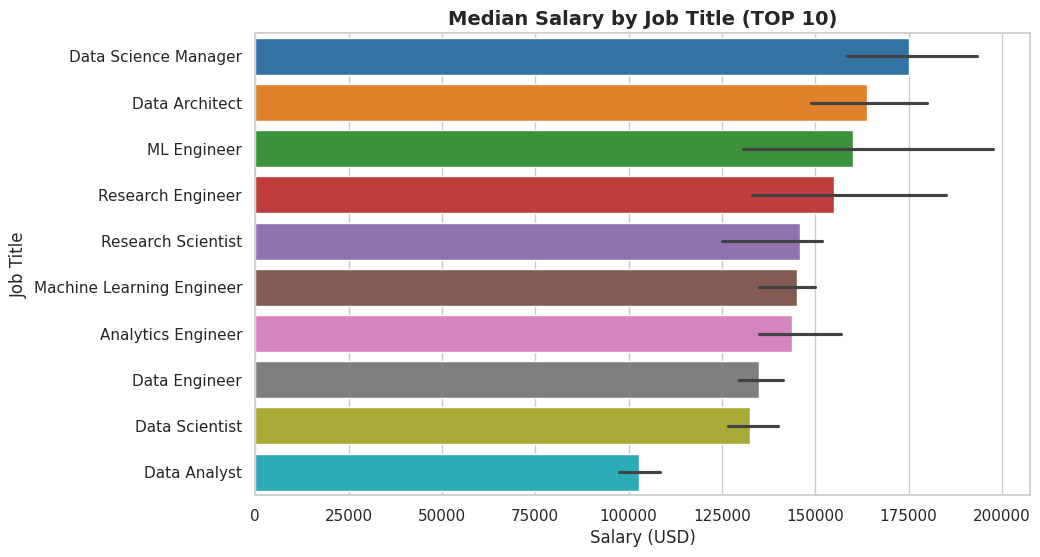

In [37]:
top_jobs = jobs["job_title"].value_counts().head(10).index

df_jobs = jobs[jobs["job_title"].isin(top_jobs)]

order = df_jobs.groupby("job_title")["salary_in_usd"].median().sort_values(ascending=False).index

sns.barplot(
    x="salary_in_usd",
    y="job_title",
    data=df_jobs,
    estimator=np.median,
    order=order,
    palette="tab10"
)

plt.title("Median Salary by Job Title (TOP 10)")
plt.xlabel("Salary (USD)")
plt.ylabel("Job Title")

plt.show()

Among the most frequently occurring roles in the dataset, managerial and specialized engineering positions command the highest salaries, while Data Analyst remains the entry-level benchmark at ~$103K. Notably, the ML Engineer role shows the widest salary variability, as seen by its long error bar, indicating high earning potential but inconsistent pay across companies.

## **Salary Trend Over Time**

In [38]:
jobs.groupby('work_year')['salary_in_usd'].median()

,salary_in_usd
work_year,
2020,74130.0
2021,80000.0
2022,129300.0
2023,140000.0


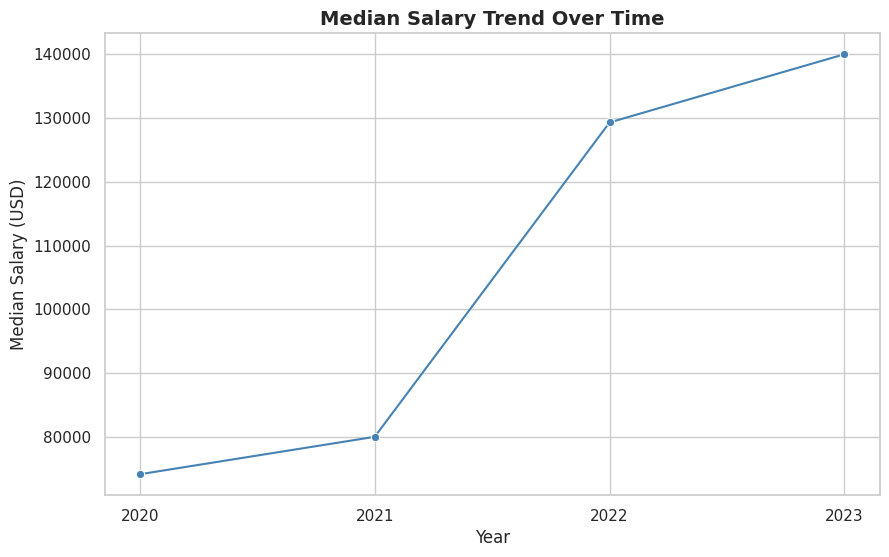

In [39]:
yearly_salary = jobs.groupby('work_year')['salary_in_usd'].median().reset_index()

sns.lineplot(
    x='work_year',
    y='salary_in_usd',
    data=yearly_salary,
    marker='o',
    color='steelblue'
)

plt.title('Median Salary Trend Over Time')
plt.xlabel('Year')
plt.ylabel('Median Salary (USD)')
plt.xticks([2020, 2021, 2022, 2023])
plt.show()

Data science salaries nearly doubled between 2020 and 2023, with the most dramatic increase occurring between 2021 and 2022. This sharp mid-period jump likely reflects the post-pandemic tech boom and the growing recognition of data science as a critical business function.

## **Employment Type Analysis**

In [40]:
jobs['employment_type'].value_counts()

,count
employment_type,
FT,2547
PT,17
CT,10
FL,10


In [41]:
# Median salary per employment type
jobs.groupby('employment_type')['salary_in_usd'].median().sort_values(ascending=False)

,salary_in_usd
employment_type,
FT,130000.0
CT,75000.0
FL,50000.0
PT,21669.0


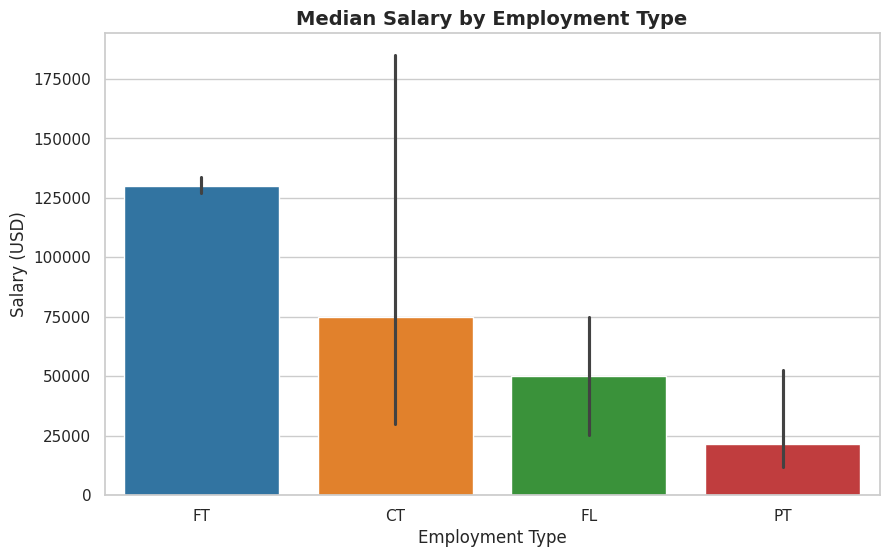

In [42]:
emp_order = jobs.groupby('employment_type')['salary_in_usd'].median().sort_values(ascending=False).index

sns.barplot(
    x='employment_type',
    y='salary_in_usd',
    data=jobs,
    estimator=np.median,
    order=emp_order,
    palette='tab10'
)

plt.title('Median Salary by Employment Type')
plt.xlabel('Employment Type')
plt.ylabel('Salary (USD)')
plt.show()

Full-time employment dominates the dataset and offers the highest and most consistent median salary at $130,000. The other employment type, such as Contract, Freelance, and Part-Time, they have too few entries to draw strong conclusions, though their wide error bars suggest high variability in pay that likely depends on individual arrangements rather than market standards

# ________________________________________________________________________________________________________________

# **Key Insights**

 1. **Experience level is the strongest salary driver.** Median salary grows consistently from ~62K USD (Entry-level) to ~190K USD (Executive), nearly tripling across career stages. However, job role and location can sometimes override experience — as seen in mid-level roles earning above 400K USD.

 2. **Medium-sized companies pay the most.** Despite large companies being associated with bigger budgets, medium-sized companiesoffer the highest median salary at ~137K USD, suggesting a competitive edge in attracting talent.

 3. **On-site roles pay slightly more than remote.** On-site positions lead at 137,500 USD, followed closely by remote at 130,000 USD. Thedifference is small, suggesting work arrangement alone is not a strong salarydeterminant.

 4. **The US is the most reliable market.** While Israel and Puerto Rico show higher median salaries, their small sample sizesmake these figures less dependable. The US offers the best balance of competitivepay and job volume.

 5. **Data science salaries nearly doubled from 2020 to 2023.** The sharpest growth occurred between 2021 and 2022, likely driven by thepost-pandemic tech boom and increased demand for data-driven decision-making.

 6. **Full-time employment dominates and pays the most.** Over 98% of roles in the dataset are full-time, with a median salary of 130,000 USD. Other employment types are too underrepresented for reliable comparison.

 7. **Data Science Manager is the highest-paying common role.** Among the 10 most frequent job titles, Data Science Manager leads at ~175K USD, while Data Analyst serves as the entry-level benchmark at ~103K USD.

# ________________________________________________________________________________________________________________

# **Conclusion**

 This analysis of global data science salaries reveals that compensation in the field is shaped by multiple factors working together. Experience level provides the clearest salary progression, but role specialization, company size, and geographic location also play significant roles. The rapid salary growth between 2020 and 2023 underscores the increasing value placed on data science talent worldwide. For those entering or advancing in the field, targeting senior or managerial roles at medium-sized companies, particularly in the US, where it appears to offer the strongest compensation outcomes based on this dataset.

In [43]:
# # Export cleaned dataset
# from google.colab import files
# jobs.to_csv('cleaned_ds_salaries.csv', index=False)
# files.download('cleaned_ds_salaries.csv')

# ______________________________________________________________________________________________________________________
# **PURCHASING POWER ANALYSIS (BIG MAC INDEX)**

To provide a comprehensive understanding of compensation beyond raw salary figures, this section examines purchasing power across countries using the Big Mac Index, an informal measure of cost of living developed by The Economist.


In [44]:
bigmac = pd.read_csv('https://raw.githubusercontent.com/jecka0627/ds_global_job_salaries/refs/heads/main/big-mac-full-index.csv')

## **Understanding the Data**

In [45]:
# Display basic information
print("Dataset Shape:", bigmac.shape)

Dataset Shape: (1894, 19)


In [46]:
print("\nColumn Names and Data Types:")
print(bigmac.dtypes)


Column Names and Data Types:
date              object
iso_a3            object
currency_code     object
name              object
local_price      float64
dollar_ex        float64
dollar_price     float64
USD_raw          float64
EUR_raw          float64
GBP_raw          float64
JPY_raw          float64
CNY_raw          float64
GDP_bigmac       float64
adj_price        float64
USD_adjusted     float64
EUR_adjusted     float64
GBP_adjusted     float64
JPY_adjusted     float64
CNY_adjusted     float64
dtype: object


In [47]:
print("\nFirst 10 rows:")
print(bigmac.head(10))


First 10 rows:
         date iso_a3 currency_code            name  local_price   dollar_ex  \
0  2000-04-01    ARG           ARS       Argentina         2.50    1.000000   
1  2000-04-01    AUS           AUD       Australia         2.59    1.680000   
2  2000-04-01    BRA           BRL          Brazil         2.95    1.790000   
3  2000-04-01    CAN           CAD          Canada         2.85    1.470000   
4  2000-04-01    CHE           CHF     Switzerland         5.90    1.700000   
5  2000-04-01    CHL           CLP           Chile      1260.00  514.000000   
6  2000-04-01    CHN           CNY           China         9.90    8.280000   
7  2000-04-01    CZE           CZK  Czech Republic        54.37   39.100000   
8  2000-04-01    DNK           DKK         Denmark        24.75    8.040000   
9  2000-04-01    EUZ           EUR       Euro area         2.56    1.075269   

   dollar_price  USD_raw  EUR_raw  GBP_raw  JPY_raw  CNY_raw    GDP_bigmac  \
0      2.500000  0.11607  0.05007 -0

In [48]:
print("\nBasic Statistics:")
print(bigmac.describe())


Basic Statistics:
        local_price     dollar_ex  dollar_price      USD_raw      EUR_raw  \
count  1.894000e+03  1.894000e+03   1894.000000  1894.000000  1894.000000   
mean   1.769941e+04  5.188830e+03      3.467605    -0.160225    -0.237531   
std    3.998899e+05  1.020723e+05      1.318122     0.311021     0.263413   
min    1.050000e+00  3.008000e-01      0.639966    -0.845150    -0.834710   
25%    8.000000e+00  3.074300e+00      2.469535    -0.385728    -0.432227   
50%    2.850000e+01  7.800450e+00      3.299551    -0.212020    -0.273355   
75%    1.397500e+02  5.231990e+01      4.290000     0.000000    -0.082318   
max    1.602000e+07  3.613989e+06      9.081066     1.534720     0.870630   

           GBP_raw      JPY_raw      CNY_raw     GDP_bigmac    adj_price  \
count  1894.000000  1894.000000  1894.000000    1645.000000  1645.000000   
mean     -0.185552     0.097267     0.401066   25744.763284     3.594637   
std       0.288548     0.408353     0.594792   21250.968735

The Big Mac Index dataset spans over two decades of data, containing 1,894 records
of Big Mac prices across countries. Each record includes the date, a 3-letter country
code (iso_a3), country name, and the Big Mac price converted to USD. This long-term
and global coverage allows us to compare purchasing power across the top 10 data
science salary countries in our analysis.

**Key Dataset Characteristics:**
- **Time Range:** 2000 to present (20+ years of data)
- **Records:** 1,894 observations across multiple countries
- **Country Identification:** 3-letter ISO codes (e.g., ARG, AUS, USA, CHE)
- **Primary Metric:** Big Mac price in USD (dollar_price), serving as a proxy for
cost of living and currency valuation

## **Big Mac Index Exploratory Analysis**

Before analyzing purchasing power, I'm exploring the Big Mac Index dataset
to understand price distributions, trends, and variations across countries.

### **DISTRIBUTION**

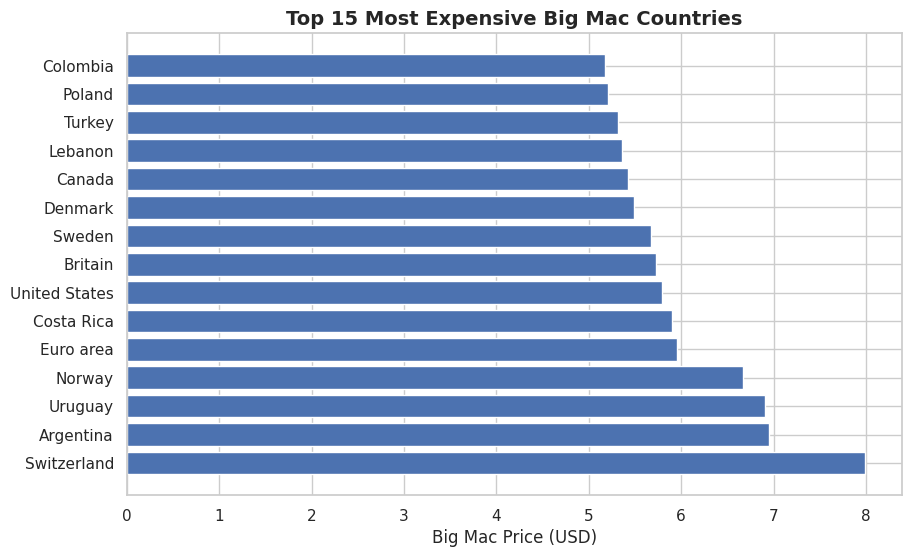

In [49]:
# I'm showing the distribution of Big Mac prices across all countries to understand the range and variation in cost of living globally.

bigmac_latest = bigmac[bigmac['date'] == bigmac['date'].max()]
top_15 = bigmac_latest.nlargest(15, 'dollar_price')

plt.figure(figsize=(10, 6))
plt.barh(top_15['name'], top_15['dollar_price'])
plt.xlabel('Big Mac Price (USD)')
plt.title('Top 15 Most Expensive Big Mac Countries')
plt.show()

### **TREND OVER TIME**

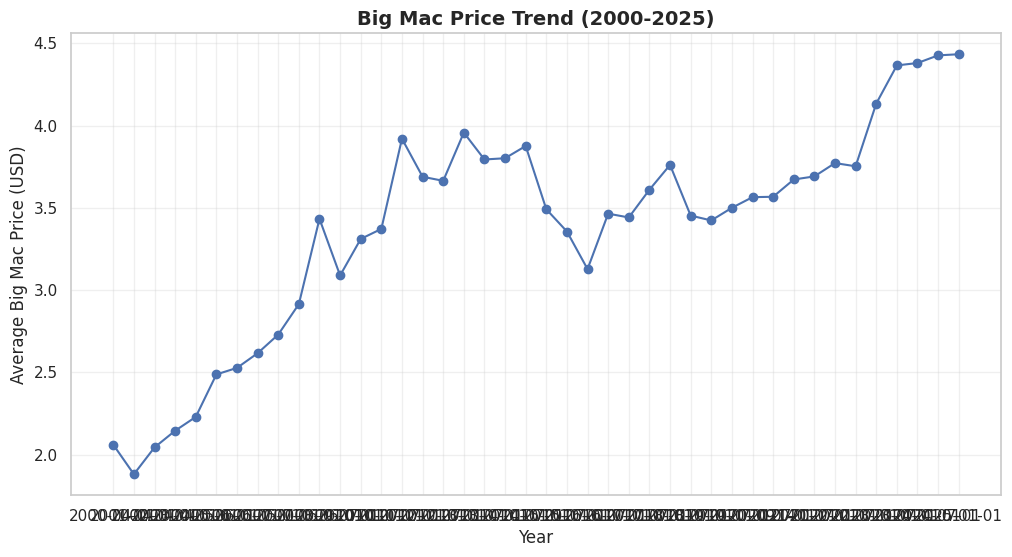

In [50]:
trend = bigmac.groupby('date')['dollar_price'].mean()

plt.figure(figsize=(12, 6))
plt.plot(trend.index, trend.values, marker='o')
plt.xlabel('Year')
plt.ylabel('Average Big Mac Price (USD)')
plt.title('Big Mac Price Trend (2000-2025)')
plt.grid(alpha=0.3)
plt.show()

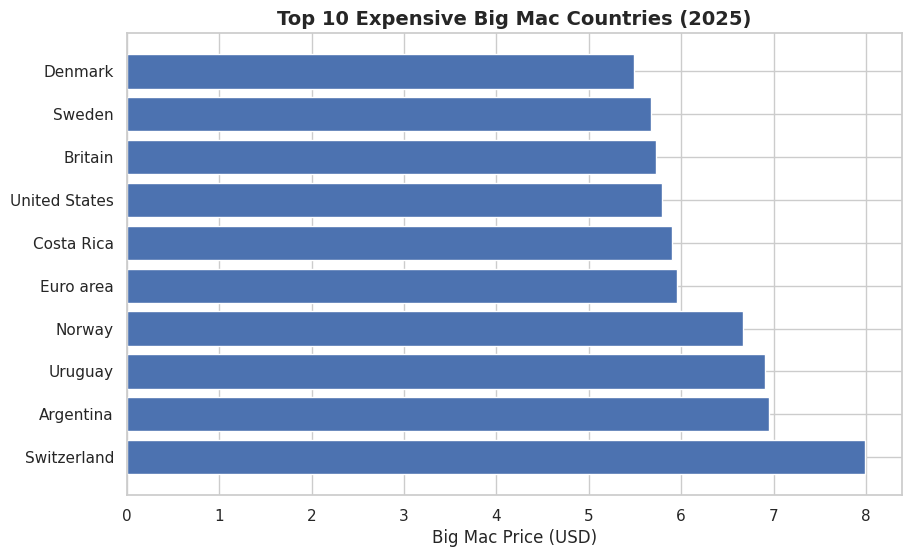

In [51]:
top_10 = bigmac_latest.nlargest(10, 'dollar_price')

plt.figure(figsize=(10, 6))
plt.barh(top_10['name'], top_10['dollar_price'])
plt.xlabel('Big Mac Price (USD)')
plt.title('Top 10 Expensive Big Mac Countries (2025)')
plt.show()

### **Key Observations from Big Mac Data**

- Big Mac prices vary significantly across countries, ranging from under 2 to nearly 8 USD
- The average global Big Mac price has roughly doubled from 2000 to 2025
- Developed European countries (Switzerland, Norway, Denmark) consistently have the highest prices
- These price variations demonstrate why purchasing power analysis is essential for comparing salaries across countries

## **Aligning Datasets for Purchasing Power Calculation**

Before calculating purchasing power, I need to identify which countries from my
salary analysis have corresponding Big Mac price data. This step retrieves the
latest Big Mac prices and compares them with my top 10 salary countries to
determine data availability for the analysis.

### **Get the latest Big Mac data available**
I'm extracting the most recent Big Mac price data to ensure I'm using current cost of living indicators for my purchasing power analysis.

In [52]:
latest_date = bigmac['date'].max()
bigmac_latest = bigmac[bigmac['date'] == latest_date].copy()

print(f"Latest Big Mac data date: {latest_date}")
print(f"\nLatest Big Mac prices by country:")
print(bigmac_latest[['iso_a3', 'name', 'dollar_price']].sort_values('dollar_price', ascending=False).head(15))

Latest Big Mac data date: 2025-01-01

Latest Big Mac prices by country:
     iso_a3           name  dollar_price
1847    CHE    Switzerland      7.992452
1841    ARG      Argentina      6.952380
1889    URY        Uruguay      6.910099
1873    NOR         Norway      6.674498
1855    EUZ      Euro area      5.952943
1851    CRI     Costa Rica      5.901801
1890    USA  United States      5.790000
1856    GBR        Britain      5.725762
1884    SWE         Sweden      5.668960
1853    DNK        Denmark      5.487007
1846    CAN         Canada      5.429455
1868    LBN        Lebanon      5.360134
1886    TUR         Turkey      5.316135
1879    POL         Poland      5.210476
1850    COL       Colombia      5.174589


### **Get top 10 countries from my salary analysis**
I'm retrieving the top 10 countries ranked by median data science salary to prepare them for comparison with their respective Big Mac prices.

In [53]:
print("\n\nTop 10 Countries by Median Salary:")
top_10_salary = jobs.groupby('company_location')['salary_in_usd'].median().sort_values(ascending=False).head(10)
print(top_10_salary)



Top 10 Countries by Median Salary:
company_location
IL    271446.5
PR    167500.0
US    145885.0
NZ    125000.0
BA    120000.0
CA    120000.0
AE    115000.0
RU    106000.0
SE    105000.0
CH    104697.0
Name: salary_in_usd, dtype: float64


### **FINDINGS:**

The latest Big Mac price data is from January 2025. Among my top 10 salary countries, I can see some matches with the Big Mac dataset:

- **Switzerland (CHE):** Big Mac = 7.99 USD | Median Salary = 104,697 USD
- **Canada (CAN):** Big Mac = 5.43 USD | Median Salary = 120,000 USD
- **Sweden (SWE):** Big Mac = 5.67 USD | Median Salary = 105,000 USD
- **United States (USA):** Big Mac = 5.79 USD | Median Salary = 145,885 USD

However, some countries from my top 10 (Israel, Puerto Rico, New Zealand, Bosnia, UAE, Russia) use different 3-letter codes in the Big Mac dataset. In the next step, I will create a mapping table to convert my 2-letter country codes to the 3-letter ISO codes used in the Big Mac dataset.

## **Creating Country Code Mapping**

My salary dataset uses 2-letter ISO country codes while the Big Mac dataset uses 3-letter codes. I'm creating a mapping table to convert my top 10 salary countries to their corresponding 3-letter codes, then checking which ones are available in the Big Mac data.

In [54]:
# Create a mapping from 2-letter to 3-letter country codes
code_mapping = {
    'IL': 'ISR',  # Israel
    'PR': 'PRI',  # Puerto Rico
    'US': 'USA',  # United States
    'NZ': 'NZL',  # New Zealand
    'BA': 'BIH',  # Bosnia
    'CA': 'CAN',  # Canada
    'AE': 'ARE',  # UAE
    'RU': 'RUS',  # Russia
    'SE': 'SWE',  # Sweden
    'CH': 'CHE',  # Switzerland
}

# Check which countries are available in Big Mac data
print("Checking Big Mac data availability:")
print(code_mapping)

# See what countries are in the latest Big Mac data
print("\nCountries in Big Mac data (latest):")
print(bigmac_latest['iso_a3'].unique())

Checking Big Mac data availability:
{'IL': 'ISR', 'PR': 'PRI', 'US': 'USA', 'NZ': 'NZL', 'BA': 'BIH', 'CA': 'CAN', 'AE': 'ARE', 'RU': 'RUS', 'SE': 'SWE', 'CH': 'CHE'}

Countries in Big Mac data (latest):
['ARE' 'ARG' 'AUS' 'AZE' 'BHR' 'BRA' 'CAN' 'CHE' 'CHL' 'CHN' 'COL' 'CRI'
 'CZE' 'DNK' 'EGY' 'EUZ' 'GBR' 'GTM' 'HKG' 'HND' 'HUN' 'IDN' 'IND' 'ISR'
 'JOR' 'JPN' 'KOR' 'KWT' 'LBN' 'MDA' 'MEX' 'MYS' 'NIC' 'NOR' 'NZL' 'OMN'
 'PAK' 'PER' 'PHL' 'POL' 'QAT' 'ROU' 'SAU' 'SGP' 'SWE' 'THA' 'TUR' 'TWN'
 'UKR' 'URY' 'USA' 'VEN' 'VNM' 'ZAF']


### **Mapping Results**

Out of my top 10 salary countries, 7 have Big Mac price data available:

**Available (7):**
- IL (Israel) - ISR
- US (United States) - USA
- NZ (New Zealand) - NZL
- CA (Canada) - CAN
- AE (United Arab Emirates) - ARE
- SE (Sweden) - SWE
- CH (Switzerland) - CHE

**Not available (3):**
- PR (Puerto Rico) - PRI
- BA (Bosnia) - BIH
- RU (Russia) - RUS

I will proceed with the 7 available countries for my purchasing power analysis.

### **Merging Salary and Big Mac Data**

Now I'm combining the salary data from my top 10 countries with their corresponding Big Mac prices. This will allow me to calculate purchasing power by comparing how many Big Macs a data scientist can afford annually in each country.

In [55]:
# Get top 10 countries and their median salaries
# I'm extracting my top 10 salary countries to prepare for merging with Big Mac data.

top_10 = jobs.groupby('company_location')['salary_in_usd'].median().sort_values(ascending=False).head(10)
top_10_df = top_10.reset_index()
top_10_df.columns = ['country_2letter', 'median_salary']

print("Top 10 Countries by Median Salary:")
print(top_10_df)

Top 10 Countries by Median Salary:
  country_2letter  median_salary
0              IL       271446.5
1              PR       167500.0
2              US       145885.0
3              NZ       125000.0
4              BA       120000.0
5              CA       120000.0
6              AE       115000.0
7              RU       106000.0
8              SE       105000.0
9              CH       104697.0


In [56]:
# Add 3-letter country codes to salary data
# I'm adding the mapped 3-letter codes so I can match with Big Mac data.

top_10_df['country_3letter'] = top_10_df['country_2letter'].map(code_mapping)

print("\nWith 3-letter codes added:")
print(top_10_df)


With 3-letter codes added:
  country_2letter  median_salary country_3letter
0              IL       271446.5             ISR
1              PR       167500.0             PRI
2              US       145885.0             USA
3              NZ       125000.0             NZL
4              BA       120000.0             BIH
5              CA       120000.0             CAN
6              AE       115000.0             ARE
7              RU       106000.0             RUS
8              SE       105000.0             SWE
9              CH       104697.0             CHE


In [57]:
# Get Big Mac prices for available countries
# I'm extracting Big Mac prices only for countries that have data.

bigmac_filtered = bigmac_latest[['iso_a3', 'name', 'dollar_price']].copy()
bigmac_filtered.columns = ['country_3letter', 'country_name', 'bigmac_price']

print("\nBig Mac prices sample:")
print(bigmac_filtered.head())


Big Mac prices sample:
     country_3letter          country_name  bigmac_price
1840             ARE  United Arab Emirates      4.900760
1841             ARG             Argentina      6.952380
1842             AUS             Australia      4.870488
1843             AZE            Azerbaijan      3.670588
1844             BHR               Bahrain      4.509284


In [58]:
# Merge the two datasets
# I'm combining salary and Big Mac data based on matching country codes.

merged_data = top_10_df.merge(bigmac_filtered, on='country_3letter', how='inner')

print("\nMerged Data (Salary + Big Mac):")
print(merged_data)


Merged Data (Salary + Big Mac):
  country_2letter  median_salary country_3letter          country_name  \
0              IL       271446.5             ISR                Israel   
1              US       145885.0             USA         United States   
2              NZ       125000.0             NZL           New Zealand   
3              CA       120000.0             CAN                Canada   
4              AE       115000.0             ARE  United Arab Emirates   
5              SE       105000.0             SWE                Sweden   
6              CH       104697.0             CHE           Switzerland   

   bigmac_price  
0      4.714692  
1      5.790000  
2      4.774140  
3      5.429455  
4      4.900760  
5      5.668960  
6      7.992452  


### **Merged Data Summary**

The merge successfully combined salary and Big Mac price data for 7 countries. The resulting dataset includes:

- **Israel (IL):** Median Salary 271,446.50 USD | Big Mac Price 4.71 USD
- **United States (US):** Median Salary 145,885.00 USD | Big Mac Price 5.79 USD
- **New Zealand (NZ):** Median Salary 125,000.00 USD| Big Mac Price 4.77 USD
- **Canada (CA):** Median Salary 120,000.00 USD| Big Mac Price 5.43 USD
- **UAE (AE):** Median Salary 115,000.00 USD| Big Mac Price 4.90 USD
- **Sweden (SE):** Median Salary 105,000.00 USD | Big Mac Price 5.67 USD
- **Switzerland (CH):** Median Salary 104,697.00 USD | Big Mac Price 7.99 USD

Three countries (Puerto Rico, Bosnia, Russia) could not be matched and were excluded from this analysis.


## **Calculating Annual Purchasing Power**

To measure purchasing power, I'm calculating how many Big Macs a data scientist can afford annually in each country. This provides a simple yet effective indicator of the real value of their salary when accounting for cost of living.

In [59]:
# Calculate annual Big Mac purchasing power
merged_data['annual_bigmacs'] = merged_data['median_salary'] / merged_data['bigmac_price']

# Sort by purchasing power (highest to lowest)
purchasing_power = merged_data[['country_name', 'median_salary', 'bigmac_price', 'annual_bigmacs']].sort_values('annual_bigmacs', ascending=False)

print("Purchasing Power Ranked (Highest to Lowest):")
print(purchasing_power)

Purchasing Power Ranked (Highest to Lowest):
           country_name  median_salary  bigmac_price  annual_bigmacs
0                Israel       271446.5      4.714692    57574.601022
2           New Zealand       125000.0      4.774140    26182.726104
1         United States       145885.0      5.790000    25196.027634
4  United Arab Emirates       115000.0      4.900760    23465.750000
3                Canada       120000.0      5.429455    22101.664533
5                Sweden       105000.0      5.668960    18521.915323
6           Switzerland       104697.0      7.992452    13099.485063


# **Purchasing Power Findings**

When I calculated purchasing power across the 7 countries with Big Mac data,
I discovered something important: the sample sizes vary dramatically. Let me break this down because it matters for understanding what I'm seeing.

**Sample size by country:**
- United States: 1,929 records
- Canada: 83 records
- Switzerland: 5 records
- United Arab Emirates: 3 records
- Israel: 2 records
- Sweden: 2 records
- New Zealand: 1 record

**What this means:** I can confidently talk about the US. For everyone else,
I'm working with very limited data.

**The reliable finding:**
The United States shows a median salary of 146,000 USD with an average Big Mac price of 5.79 USD, which means a data scientist can afford about 25,196 Big Macs annually. This is based on nearly 2,000 data points, so it's solid.

**The interesting but limited findings:**
Israel appears to have the highest purchasing power at 57,574 Big Macs annually, but this is based on only 2 salary records. New Zealand looks like it offers great value at 26,182 Big Macs, but that's from just 1 record. So while these are interesting patterns, I can't really say they're reliable conclusions.

**Bottom line:** The US data is trustworthy. Everything else is exploratory
and shouldn't be used to make career decisions.

### **Overall Insight:**

Looking at the Big Mac Index over 25 years, I found that cost of living varies
dramatically across countries. Big Macs range from about 2.50 USD to nearly 8 USD, and prices have roughly doubled since 2000. Europe is consistently the most expensive (Switzerland at 8 USD, Sweden at 5.67 USD), while other regions are much cheaper.

This is why I did the purchasing power analysis in the first place because a high salary doesn't automatically mean you're better off financially. You need to factor in what things actually cost.

But here's what I discovered while building my dashboard: when I tried to combine salary data with Big Mac prices for all 7 countries, I realized the US is the only country where I have enough salary data to draw reliable conclusions. Every other country has very few salary records (between 1 and 83), so while I can calculate their purchasing power, it's not trustworthy.

The real takeaway: US data scientists earn competitive salaries globally at around 146K USD, and they can afford a reasonable amount with that salary. For other countries, I'm seeing patterns, but I don't have enough data to say they're real.